#**비지도학습(Unsupervised Learning)**

##1. 군집화(Clustering)
(1) K-Means
- 데이터를 K개의 군집으로나누는 알고리즘
-각 군집의 중심(centroid)을 반복적으로 업데이트하며 최적화
- 초기 중심 설정에 따라 결과가 달라질 수 있음

(2) 계층적 군집화(Hierarchical Clustering)
- 데이터 간의 유사성을 기반으로 계층적으로 군집을 형성
- 상향식과 하향식 방법 존재
- 결과를 덴드로그램으로 시각화 가능

(3)DBSCAN
- 밀도 기반의 군집화 기법으로 노이즈 데이터를 효과적으로 처리 가능
- K-Means처럼 군집 개수를 미리 정할 필요가 없음
- 밀도가 높은 지역을 군집으로 묶고, 밀도가 낮은 데이터는 이상치로 처리

(4)GMM(Gaussian Mixture Model)
- 데이터가 여러 개의 가우시안 분포로 구성되어 있다고 가정하는 확률적 군집화 방법
- EM 알고리즘을 사용하여 군집을 찾음
- K-Means보다 유연하며, 데이터가 중첩된 경우에도 잘 작동

##2. 차원 축소(Dimensionality Reduction)

(1) PCA(Principal Component Analysis)
- 고차원의 데이터를 저차원으로 변환하여 핵심 정보를 유지하는 기법
- 데이터의 분산이 가장 큰 방향으로 새로운 축을 생성하여 차원을 축소
- 데이터 시각화, 노이즈 제거 등에 활용됨

(2) t-SNE
- 고차원 데이터를 2D 또는 3D로 변환하여 시각화하는 비선형 차원 축소 기법
- 유사한 데이터 포인트를 가깝게 배치하여 시각적 해석이 용이
- 대규모 데이터셋에서는 계산 비용이 높음

(3) UMAP
- t-SNE와 유사하지만 더 빠르고 글로벌 구조를 잘 유지하는 차원 축소 기법
- 데이터의 군집 구조를 보존하면서 시각화를 수행

(4) Autoencoder
- 인코더-디코더 구조를 활용한 신경망 기반 차원 축소 기법
- 중간 계층에서 중요한 특징만을 추출하여 차원을 줄임
- 이미지 복원, 이상 탐지 등에 활용 가능

##3. 이상 탐지(Anomaly Detection)

(1) Isolation Forest
- 데이터의 이상값을 감지하는 트리 기반 알고리즘
- 정상 데이터는 비교적 깊은 노드에 위치하고, 이상치는 빠르게 분리됨
- 효율적으로 이상치를 탐지

(2) One-Class SVM
- SVM을 활용하여 정상 데이터의 경계를 학습하고, 경계를 벗어난 데이터를 이상치로 판별
- 고차원 데이터에서도 적용 가능하지만, 데이터 크기가 크면 학습 시간이 오래 걸릴 수 있음

(3) Autoencoder 기반 이상 탐지
- 정상 데이터로 Autoencoder를 학습한 후, 재구성 오류가 큰 데이터를 이상치로 판단
- 금융 사기 탐지, 네트워크 침입 탐지 등에 활용

##4. 연관 규칙 학습(Association Rule Learning)
 (1) Apriori 알고리즘
 - 데이터에서 자주 발생하는 항목 집합을 찾아 연관 규칙을 생성하는 알고리즘
 - 대형 마켓에서 상품 간의 연관성 분석에 사용됨

 (2)FP-Growth (Frequent Pattern Growth)
 - Apriori보다 효율적으로 빈발 패턴을 찾는 알고리즘
 - 데이터가 많을 때 Apriori보다 빠르게 동작

##5. Generative Models
 (1) GAN
 - 생성자와 판별자가 경쟁하는 구조를 통해 데이터를 생성하는 모델
 - 이미지 생성, 데이터 증강 등에 활용

(2) VAE(Variational Autoencoder)
- 확률 모델을 활용한 생성 모델로, 데이터의 분포를 학습하여 새로운 데이터를 생성
- 얼굴 합성, 이미지 변환 등에 사용됨



In [1]:
import numpy as np

from sklearn.datasets import load_digits

data, labels = load_digits(return_X_y=True)
(n_samples, n_features), n_digits = data.shape, np.unique(labels).size

print(f"# digits: {n_digits}; # samples: {n_samples}; # features {n_features}")

# digits: 10; # samples: 1797; # features 64


In [2]:
from time import time

from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def bench_k_means(kmeans, name, data, labels):
    """Benchmark to evaluate the KMeans initialization methods.

    Parameters
    ----------
    kmeans : KMeans instance
        A :class:`~sklearn.cluster.KMeans` instance with the initialization
        already set.
    name : str
        Name given to the strategy. It will be used to show the results in a
        table.
    data : ndarray of shape (n_samples, n_features)
        The data to cluster.
    labels : ndarray of shape (n_samples,)
        The labels used to compute the clustering metrics which requires some
        supervision.
    """
    t0 = time()
    estimator = make_pipeline(StandardScaler(), kmeans).fit(data)
    fit_time = time() - t0
    results = [name, fit_time, estimator[-1].inertia_]

    # Define the metrics which require only the true labels and estimator
    # labels
    clustering_metrics = [
        metrics.homogeneity_score,
        metrics.completeness_score,
        metrics.v_measure_score,
        metrics.adjusted_rand_score,
        metrics.adjusted_mutual_info_score,
    ]
    results += [m(labels, estimator[-1].labels_) for m in clustering_metrics]

    # The silhouette score requires the full dataset
    results += [
        metrics.silhouette_score(
            data,
            estimator[-1].labels_,
            metric="euclidean",
            sample_size=300,
        )
    ]

    # Show the results
    formatter_result = (
        "{:9s}\t{:.3f}s\t{:.0f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}"
    )
    print(formatter_result.format(*results))

In [3]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print(82 * "_")
print("init\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette")

kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=4, random_state=0)
bench_k_means(kmeans=kmeans, name="k-means++", data=data, labels=labels)

kmeans = KMeans(init="random", n_clusters=n_digits, n_init=4, random_state=0)
bench_k_means(kmeans=kmeans, name="random", data=data, labels=labels)

pca = PCA(n_components=n_digits).fit(data)
kmeans = KMeans(init=pca.components_, n_clusters=n_digits, n_init=1)
bench_k_means(kmeans=kmeans, name="PCA-based", data=data, labels=labels)

print(82 * "_")

__________________________________________________________________________________
init		time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
k-means++	0.337s	69545	0.598	0.645	0.621	0.469	0.617	0.162
random   	0.263s	69735	0.681	0.723	0.701	0.574	0.698	0.168
PCA-based	0.124s	69513	0.600	0.647	0.622	0.468	0.618	0.151
__________________________________________________________________________________


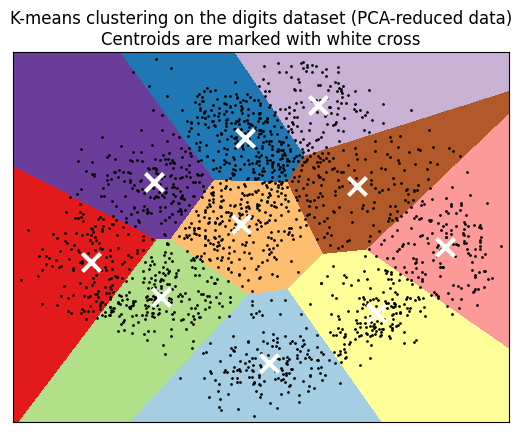

In [4]:
import matplotlib.pyplot as plt

reduced_data = PCA(n_components=2).fit_transform(data)
kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=4)
kmeans.fit(reduced_data)

# Step size of the mesh. Decrease to increase the quality of the VQ.
h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on the digits dataset (PCA-reduced data)\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()